# Анализ данных

Количественные величины:
- длительность фильма
- длина плана
- часть фильма
- количество лиц
- площадь лица
- количество объектов/контуров
- яркость
- дата релиза (год, месяц, день)
- рейтинг

Категориальные величины:
- фильм (название)
- жанр (и доп. жанры)
- режиссер
- сценарист
- главные роли
- возрастной рейтинг
- награды


+ общее количество кадров и планов, количество глаз

## Подготовка данных

(Технические детали: импорт нужных библиотек, загрузка файлов, создание вспомогательных столбцов)

In [102]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

In [2]:
shot_df = pd.read_csv('db_dvt_data.csv', header=0, index_col=0)
frames_df = pd.read_csv('db_frames.csv', header=0)
metadata_df = pd.read_csv('db_metadata.csv', header=0, index_col=0)

In [3]:
metadata_df['released'] = pd.to_datetime(metadata_df['released'])
metadata_df['month'] = metadata_df['released'].dt.month # месяц выпуска

In [4]:
# время в минутах
shot_df['time_minute'] = shot_df['timecode'].apply(lambda x: int(x.split(':')[0])*60 + int(x.split(':')[1]))

In [5]:
# соединяем таблицы между собой
frames_df = pd.merge(frames_df, shot_df, on=['title', 'shot_index'], how='left')
frames_df = frames_df.drop(['start', 'end'], axis=1)
# убираем кадры из титров из анализа
frames_df = frames_df[frames_df['shot_index'] >= 0]

In [6]:
# 1 если есть хотя бы одно лицо, 0 если лиц нет
frames_df['faces_bool'] = frames_df['faces'].apply(lambda x: 1 if x > 0 else 0)

In [7]:
# функция, определяющая крупность плана
def closeup_degree(x):
    if x > 0.15:
        return "close"
    elif x > 0:
        return 'medium'
    else:
        return 'none'

frames_df['closeup'] = frames_df['fsquare'].apply(closeup_degree)

In [11]:
frames_df.isna().mean() # проверяем, что всё корректно соединилось и в данных нет пропусков

nframe        0.00
h             0.00
m             0.00
s             0.00
faces         0.00
fsquare       0.00
neyes         0.00
nobjects      0.00
brightness    0.00
shot_index    0.00
title         0.00
length        0.00
time_length   0.00
timecode      0.00
part          0.00
part_of_6     0.00
part_of_9     0.00
time_minute   0.00
faces_bool    0.00
closeup       0.00
dtype: float64

In [12]:
# таблица с кадрами, в которых обнаружено лицо
faces = frames_df[frames_df['faces'] != 0]['faces']

In [13]:
# добавление статистики по планам разной "крупности"
def get_closeup_data(df):
    data = df['closeup'].value_counts()
    data_sum = df['closeup'].count()
    none = data['none']
    medium = data['medium']
    if 'close' in data:
        close = data['close']
    else:
        close = 0
    return pd.Series({
        'none': none/data_sum,
        'medium': medium/data_sum,
        'close': close/data_sum,
    })

closeup_data = frames_df.groupby('title').apply(get_closeup_data)
metadata_df = pd.merge(metadata_df, closeup_data, on='title', how='left') # в таблице metadata_df появилась статистика по фильмам

In [14]:
# только сцены короче минуты (без учёта аномалий)
short_scenes = frames_df[(frames_df['time_length'] < 60)&(frames_df['fsquare'] > 0.1)]

In [15]:
# средняя длина сцены на фильм
metadata_df['mean_scene'] = metadata_df['title'].apply(lambda x: shot_df[shot_df['title'] == x]['length'].mean()/24)

In [16]:
# средняя длина сцены на фильм без учёта длинных сцен
metadata_df['mean_scene_short'] = metadata_df['title'].apply(lambda x: short_scenes[short_scenes['title'] == x]['length'].mean()/24)

In [17]:
# среднее по фильму по различным параметрам
for feature in ['faces_bool', 'fsquare', 'nobjects', 'brightness']:
    metadata_df[feature] = metadata_df['title'].apply(lambda x: frames_df[frames_df['title'] == x][feature].mean())

In [18]:
# техническая функция для обработки сложных столбцов (перечисление всех жанров фильма, режиссеров и пр.)
def names_correlation(kind, data_list, feature):
    sorted_list = []

    for i in data_list:
        films = metadata_df[metadata_df[kind].str.contains(i)]
        sorted_list.append((float(round(films[feature].mean(), 2)), i))
    
    print(*sorted(sorted_list), sep='\n')

## Примеры данных

In [91]:
metadata_df.sample(3)

,title,year,genre,eng_title,rus_title,frame_count,shot_count,film_start,film_end,imdb,mark,rated,released,runtime,genres,directors,writers,actors,awards,month,none,medium,close,mean_scene,mean_scene_short,faces_bool,fsquare,nobjects,brightness
186,A_Time_to_Kill,1996,crime,A Time to Kill,Время убивать,207798,2055,1517,209314,https://www.imdb.com/title/tt0117913/,7.50,R,1996-07-24,149,"Crime, Drama, Thriller",Joel Schumacher,"John Grisham, Akiva Goldsman","Matthew McConaughey, Sandra Bullock, Samuel L....",7 wins & 12 nominations total,7,0.70,0.25,0.05,4.17,6.02,0.39,0.03,126.59,51.69
226,Titanic,1997,romance,Titanic,Титаник,267747,2355,1564,269310,https://www.imdb.com/title/tt0120338/,7.80,PG-13,1997-12-19,194,"Drama, Romance",James Cameron,James Cameron,"Leonardo DiCaprio, Kate Winslet, Billy Zane",Won 11 Oscars. 126 wins & 84 nominations total,12,0.75,0.21,0.04,4.69,6.95,0.31,0.02,147.74,58.31
227,Firelight,1997,romance,Firelight,Пламя страсти,142689,595,1477,144165,https://www.imdb.com/title/tt0119125/,7.20,R,1998-09-04,103,"Drama, Romance",William Nicholson,William Nicholson,"Sophie Marceau, Stephen Dillane, Dominique Bel...",2 wins & 2 nominations total,9,0.67,0.29,0.04,9.95,9.67,0.37,0.03,55.97,45.74


In [93]:
shot_df.sample(3)

,title,shot_index,start,end,length,time_length,timecode,part,part_of_6,part_of_9,time_minute
id,,,,,,,,,,,
45635,Boys_Don't_Cry,432,57148,57197,49,2.04,0:39:41,2,3,4,39
307348,The_Frighteners,941,87822,87845,23,0.96,1:00:59,2,4,5,60
192259,Memphis_Belle,1062,138856,138882,26,1.08,1:36:25,3,6,9,96


In [94]:
frames_df.sample(3)

,nframe,h,m,s,faces,fsquare,neyes,nobjects,brightness,shot_index,title,length,time_length,timecode,part,part_of_6,part_of_9,time_minute,faces_bool,closeup
1070551,34896,0,24,14,1,0.01,0,20,36.07,356,GoldenEye,38.00,1.58,0:24:13,1.00,2.00,2.00,24.00,1,medium
499592,150576,1,44,34,2,0.00,1,185,59.15,1101,Malcolm_X,83.00,3.46,1:44:33,2.00,4.00,5.00,104.00,1,none
1275283,32400,0,22,30,1,0.01,0,225,32.79,300,Bullet,287.00,11.96,0:22:24,1.00,2.00,3.00,22.00,1,medium


## Описательные статистики

In [20]:
frames_df[['faces', 'fsquare', 'neyes', 'nobjects', 'brightness']].describe() #.apply(lambda s: s.apply('{:,.2f}'.format))

,faces,fsquare,neyes,nobjects,brightness
count,2041499.00,2041499.00,2041499.00,2041499.00,2041499.00
mean,0.42,0.02,0.37,153.18,52.87
std,0.71,0.05,0.78,174.13,29.70
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,46.00,30.60
50%,0.00,0.00,0.00,100.00,48.02
75%,1.00,0.01,0.00,198.00,69.92
max,23.00,0.66,37.00,10804.00,255.00


In [21]:
shot_df['time_length'].describe()

count   392088.00
mean         5.20
std          7.38
min          0.04
25%          1.92
50%          3.17
75%          5.75
max        493.67
Name: time_length, dtype: float64

In [22]:
# лица встречаются на каждом третьем кадре (+ есть нераспознанные: например, в профиль)
frames_df['faces_bool'].mean()

np.float64(0.33415495182706434)

In [23]:
# "основной" жанр фильма
metadata_df['genre'].value_counts()

genre
action      30
comedy      30
crime       30
drama       30
horror      30
romance     30
sci-fi      30
thriller    30
history     29
war         29
Name: count, dtype: int64

In [24]:
# все жанры, встретившиеся более чем в 10 процентах фильмов

genres_all = list(set(metadata_df['genres'].str.cat(sep=", ").split(', ')))
genres = []

for g in genres_all:
    share = round(metadata_df[metadata_df['genres'].str.contains(g)].shape[0]/298*100, 2)
    if share > 10:
        print(g, share) # доля (в процентах) фильмов с таким жанром
        genres.append(g)

Sci-Fi 11.41
Horror 11.74
Action 27.85
Comedy 22.48
Drama 68.12
Romance 18.79
Crime 27.18
Mystery 10.74
Thriller 21.48
Adventure 12.75


In [25]:
# у большинства фильмов возрастной рейтинг R, PG-13 и PG
metadata_df['rated'].value_counts()

rated
R            207
PG-13         55
PG            27
Not Rated      4
TV-PG          1
Unrated        1
G              1
NC-17          1
Name: count, dtype: int64

In [26]:
metadata_df['month'].value_counts().sort_index()

month
1     28
2     26
3     20
4     14
5     23
6     17
7     25
8     24
9     24
10    33
11    28
12    36
Name: count, dtype: int64

In [27]:
# режиссёры, которые встречаются в нескольких фильмах
directors_all = list(set(metadata_df['directors'].str.cat(sep=", ").split(', ')))
directors = []

for d in directors_all:
    num = metadata_df[metadata_df['directors'].str.contains(d)].shape[0]
    if num > 2:
        print(d, num)
        directors.append(d)

Steven Spielberg 4
Woody Allen 3
Clint Eastwood 3
Robert Rodriguez 4
James Cameron 3
Joel Coen 4
Neil Jordan 4
Rob Reiner 3
Abel Ferrara 4
Tony Scott 4
Oliver Stone 4
Paul Verhoeven 3
Tim Burton 5
Terry Gilliam 3
Joel Schumacher 3
David Fincher 3
Ethan Coen 4
Roland Emmerich 4
Sam Raimi 3
Ang Lee 3
Wes Craven 4
Martin Scorsese 3
Quentin Tarantino 3


In [28]:
# сценаристы, которые встречаются в нескольких фильмах
writers_all = list(set(metadata_df['writers'].str.cat(sep=", ").split(', ')))
writers = []

for w in writers_all:
    num = metadata_df[metadata_df['writers'].str.contains(w)].shape[0]
    if num > 2:
        print(w, num)
        writers.append(w)

David Mamet 3
Woody Allen 3
Dean Devlin 4
Joel Coen 4
Neil Jordan 3
Andrew Kevin Walker 3
James Cameron 3
Donald E. Stewart 3
Roland Emmerich 3
Shane Black 3
Quentin Tarantino 6
Roger Avary 3
David Twohy 4
Bruce Joel Rubin 3
Kevin Williamson 3
Stephen King 4
David Koepp 4
Tom Clancy 3
Richard LaGravenese 3
Ethan Coen 4
Steven Zaillian 3


In [29]:
# актёры, которые встречаются в нескольких фильмах
actors_all = list(set(metadata_df['actors'].str.cat(sep=", ").split(', ')))
actors = []

for a in actors_all:
    num = metadata_df[metadata_df['actors'].str.contains(a)].shape[0]
    if num > 3:
        print(a, num)
        actors.append(a)

Sharon Stone 4
Christopher Walken 4
Ralph Fiennes 6
Anthony Hopkins 10
Michael Douglas 4
Robert De Niro 7
Leon 4
Sam Neill 5
Sandra Bullock 4
Clint Eastwood 4
Willem Dafoe 5
Al Pacino 7
Winona Ryder 5
Sean Penn 4
Keanu Reeves 5
Danny Glover 4
Kevin Bacon 5
Matt Damon 4
Liam Neeson 6
Jack Nicholson 4
Bruce Willis 5
Joe Pesci 5
Jeff Bridges 4
Robert Duvall 4
Tom Cruise 5
Gary Oldman 5
John Turturro 4
Gene Hackman 4
John Cusack 4
Brad Pitt 7
Samuel L. Jackson 7
Johnny Depp 5
Harvey Keitel 4
Kevin Spacey 4
Tom Hanks 4
Nicolas Cage 5
Kevin Costner 4
Tim Robbins 4


## Зависимости между двумя параметрами

In [30]:
# доля лиц незначительно меняется (возможно, в первой части фильма больше городских планов?)
frames_df.groupby('part_of_9')['faces_bool'].mean()

part_of_9
1.00   0.29
2.00   0.35
3.00   0.35
4.00   0.35
5.00   0.35
6.00   0.34
7.00   0.34
8.00   0.32
9.00   0.31
Name: faces_bool, dtype: float64

In [31]:
# доля лица на экране не меняется
frames_df.groupby('part_of_9')['fsquare'].mean()

part_of_9
1.00   0.02
2.00   0.02
3.00   0.02
4.00   0.02
5.00   0.02
6.00   0.02
7.00   0.02
8.00   0.02
9.00   0.02
Name: fsquare, dtype: float64

In [32]:
frames_df.groupby('part_of_9').apply(get_closeup_data)

,none,medium,close
part_of_9,,,
1.00,0.76,0.21,0.03
2.00,0.71,0.25,0.04
3.00,0.71,0.25,0.04
4.00,0.71,0.25,0.04
5.00,0.71,0.25,0.04
6.00,0.72,0.24,0.04
7.00,0.71,0.24,0.04
8.00,0.73,0.22,0.04
9.00,0.74,0.21,0.04


In [33]:
# кадры постепенно упрощаются?
frames_df.groupby('part_of_9')['nobjects'].mean()

part_of_9
1.00   166.12
2.00   161.37
3.00   154.27
4.00   156.45
5.00   150.01
6.00   148.28
7.00   144.33
8.00   143.54
9.00   154.08
Name: nobjects, dtype: float64

In [34]:
# кадры с крупным планом короче
frames_df.groupby('closeup')['time_length'].mean()

closeup
close     9.44
medium   14.71
none     16.06
Name: time_length, dtype: float64

In [35]:
# кадры с крупным планом более простые (само лицо занимает 15-20%, так что упрощается именно фон, возможно играет роль размытие при фокусе на лице)
frames_df.groupby('closeup')['nobjects'].mean()

closeup
close     60.66
medium   148.31
none     159.73
Name: nobjects, dtype: float64

In [36]:
# кадры в среднем чуть короче к концу фильма
shot_df.groupby('part_of_9')['time_length'].mean()

part_of_9
1   5.40
2   5.28
3   5.25
4   5.23
5   5.19
6   5.22
7   5.31
8   4.99
9   4.93
Name: time_length, dtype: float64

In [37]:
# количество планов (монтажных переходов) в разных фильмах
shot_df['title'].value_counts()

title
Armageddon               3031
Enemy_of_the_State       2964
Braveheart               2865
FaceOff                  2819
Nixon                    2603
                         ... 
Surviving_Desire          296
Deconstructing_Harry      293
The_Addiction             222
Husbands_and_Wives        210
Bullets_Over_Broadway     122
Name: count, Length: 298, dtype: int64

<Axes: xlabel='month'>

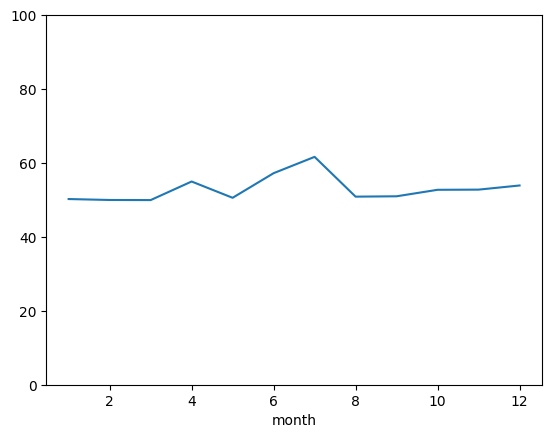

In [38]:
# средняя яркость фильма по месяцам
metadata_df.groupby('month')['brightness'].mean().plot(ylim=(0, 100))

<Axes: xlabel='month'>

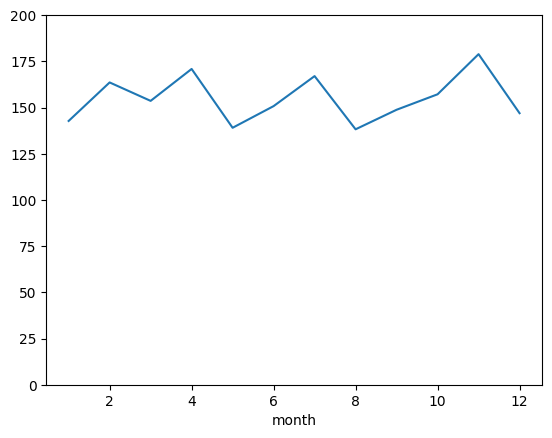

In [39]:
# средняя количество объектов на кадре по месяцам
metadata_df.groupby('month')['nobjects'].mean().plot(ylim=(0, 200))

### Жанры

причины дублирования: по столбцу "genre" (для фильма указан один, "основной" жанр) и по столбцу "genres" (все жанры фильма с imdb)

In [40]:
# длительность фильма
metadata_df.groupby('genre')['runtime'].median().sort_values()

genre
comedy     103.00
horror     106.50
sci-fi     108.50
romance    113.00
war        116.00
thriller   118.00
action     119.00
crime      119.00
history    124.00
drama      128.00
Name: runtime, dtype: float64

In [41]:
# средняя длительность плана
metadata_df.groupby('genre')['mean_scene'].mean().sort_values()

genre
action     4.07
sci-fi     4.40
war        5.52
horror     5.70
history    5.96
comedy     6.22
thriller   6.79
crime      6.92
drama      7.07
romance    8.09
Name: mean_scene, dtype: float64

In [42]:
names_correlation('genres', genres, 'mean_scene')

(4.19, 'Action')
(4.38, 'Sci-Fi')
(4.57, 'Adventure')
(5.49, 'Mystery')
(5.72, 'Thriller')
(5.77, 'Horror')
(5.89, 'Crime')
(6.53, 'Drama')
(6.77, 'Comedy')
(7.4, 'Romance')


In [43]:
# доля кадров с лицами
metadata_df.groupby('genre')['faces_bool'].mean().sort_values()

genre
sci-fi     0.28
action     0.28
war        0.29
horror     0.32
crime      0.33
thriller   0.33
history    0.35
drama      0.38
comedy     0.39
romance    0.40
Name: faces_bool, dtype: float64

In [44]:
names_correlation('genres', genres, 'faces_bool')

(0.27, 'Sci-Fi')
(0.29, 'Action')
(0.3, 'Adventure')
(0.31, 'Thriller')
(0.32, 'Crime')
(0.32, 'Horror')
(0.33, 'Mystery')
(0.35, 'Drama')
(0.37, 'Romance')
(0.38, 'Comedy')


In [45]:
# среднее количество объектов
metadata_df.groupby('genre')['nobjects'].mean().sort_values()

genre
action     124.09
horror     135.87
sci-fi     143.70
crime      144.04
thriller   144.17
drama      155.39
romance    161.31
history    166.26
war        181.80
comedy     189.03
Name: nobjects, dtype: float64

In [46]:
names_correlation('genres', genres, 'nobjects')

(133.62, 'Mystery')
(136.6, 'Sci-Fi')
(136.82, 'Thriller')
(139.18, 'Crime')
(140.3, 'Horror')
(144.58, 'Action')
(152.52, 'Romance')
(154.85, 'Drama')
(163.07, 'Adventure')
(181.52, 'Comedy')


In [47]:
# средняя яркость
metadata_df.groupby('genre')['brightness'].median().sort_values()

genre
horror     47.08
crime      48.97
action     50.34
sci-fi     51.30
thriller   51.50
drama      52.62
romance    55.28
history    55.84
war        56.01
comedy     57.68
Name: brightness, dtype: float64

In [48]:
names_correlation('genres', genres, 'brightness')

(45.22, 'Horror')
(49.83, 'Thriller')
(49.99, 'Mystery')
(50.82, 'Crime')
(51.34, 'Sci-Fi')
(52.98, 'Action')
(53.17, 'Drama')
(53.48, 'Romance')
(55.17, 'Comedy')
(57.95, 'Adventure')


In [49]:
# средняя оценка
metadata_df.groupby('genre')['mark'].mean().sort_values()

genre
war        6.56
sci-fi     6.61
horror     6.62
history    7.02
thriller   7.26
action     7.28
romance    7.42
comedy     7.42
crime      7.60
drama      7.86
Name: mark, dtype: float64

In [50]:
names_correlation('genres', genres, 'mark')

(6.7, 'Horror')
(6.78, 'Sci-Fi')
(6.82, 'Action')
(7.04, 'Mystery')
(7.12, 'Adventure')
(7.12, 'Thriller')
(7.19, 'Comedy')
(7.23, 'Romance')
(7.29, 'Drama')
(7.36, 'Crime')


In [51]:
# количество крупного плана
names_correlation('genres', genres, 'close')

(0.03, 'Adventure')
(0.03, 'Comedy')
(0.03, 'Sci-Fi')
(0.04, 'Action')
(0.04, 'Crime')
(0.04, 'Drama')
(0.04, 'Romance')
(0.04, 'Thriller')
(0.05, 'Horror')
(0.05, 'Mystery')


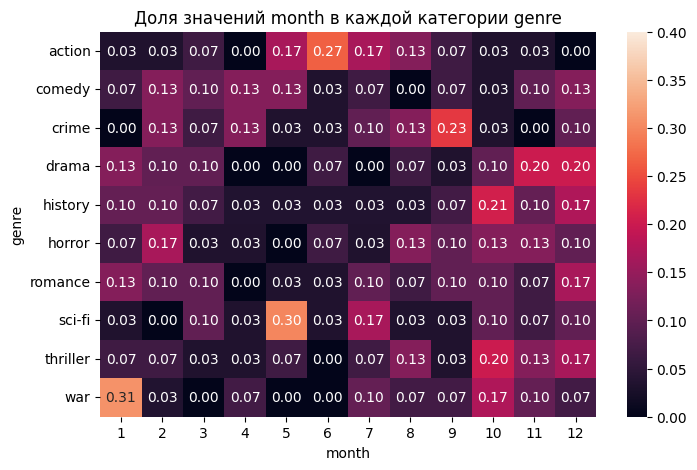

In [121]:
# тепловая карта жанров по месяцу выхода

# Создаем таблицу сопряженности с нормализацией по строкам (доля по жанру)
crosstab = pd.crosstab(metadata_df['genre'], metadata_df['month'], normalize='index')

# Строим тепловую карту
plt.figure(figsize=(8, 5))
sns.heatmap(crosstab, annot=True, cmap='rocket', vmax=0.4, fmt='.2f')
plt.title('Доля значений month в каждой категории genre')
plt.show()

### Режиссёры, сценаристы, актёры

#### Длина фильма

In [53]:
names_correlation('writers', writers, 'runtime')

(100.67, 'Woody Allen')
(109.33, 'Andrew Kevin Walker')
(109.33, 'David Mamet')
(111.5, 'Ethan Coen')
(111.5, 'Joel Coen')
(111.67, 'Kevin Williamson')
(114.67, 'Shane Black')
(115.67, 'Neil Jordan')
(119.67, 'Bruce Joel Rubin')
(120.0, 'David Koepp')
(122.25, 'David Twohy')
(124.0, 'Roger Avary')
(125.5, 'Quentin Tarantino')
(126.75, 'Dean Devlin')
(131.0, 'Donald E. Stewart')
(131.0, 'Tom Clancy')
(135.0, 'Roland Emmerich')
(140.0, 'Stephen King')
(148.0, 'Richard LaGravenese')
(148.67, 'Steven Zaillian')
(157.33, 'James Cameron')


In [54]:
names_correlation('directors', directors, 'runtime')

(92.0, 'Abel Ferrara')
(99.33, 'Sam Raimi')
(100.67, 'Woody Allen')
(103.5, 'Robert Rodriguez')
(111.25, 'Wes Craven')
(111.5, 'Ethan Coen')
(111.5, 'Joel Coen')
(113.8, 'Tim Burton')
(117.5, 'Neil Jordan')
(118.0, 'Tony Scott')
(123.0, 'Paul Verhoeven')
(123.33, 'David Fincher')
(125.0, 'Rob Reiner')
(125.67, 'Joel Schumacher')
(126.67, 'Ang Lee')
(126.75, 'Roland Emmerich')
(128.0, 'Terry Gilliam')
(134.33, 'Clint Eastwood')
(135.67, 'Quentin Tarantino')
(150.33, 'Martin Scorsese')
(157.33, 'James Cameron')
(160.0, 'Oliver Stone')
(161.5, 'Steven Spielberg')


In [55]:
names_correlation('actors', actors, 'runtime')

(96.25, 'Christopher Walken')
(108.25, 'Harvey Keitel')
(108.25, 'John Cusack')
(110.0, 'Sam Neill')
(116.4, 'Johnny Depp')
(117.25, 'Robert Duvall')
(119.0, 'John Turturro')
(120.0, 'Jeff Bridges')
(120.2, 'Winona Ryder')
(122.8, 'Keanu Reeves')
(123.2, 'Bruce Willis')
(123.25, 'Gene Hackman')
(123.25, 'Sandra Bullock')
(124.0, 'Tim Robbins')
(124.6, 'Kevin Bacon')
(125.0, 'Nicolas Cage')
(125.25, 'Michael Douglas')
(127.0, 'Jack Nicholson')
(127.75, 'Kevin Spacey')
(128.0, 'Danny Glover')
(130.2, 'Willem Dafoe')
(131.83, 'Liam Neeson')
(132.75, 'Clint Eastwood')
(132.8, 'Joe Pesci')
(133.8, 'Tom Cruise')
(135.4, 'Gary Oldman')
(136.0, 'Leon')
(138.0, 'Samuel L. Jackson')
(138.0, 'Sharon Stone')
(138.75, 'Matt Damon')
(139.0, 'Brad Pitt')
(141.25, 'Sean Penn')
(144.0, 'Al Pacino')
(144.43, 'Robert De Niro')
(145.9, 'Anthony Hopkins')
(146.33, 'Ralph Fiennes')
(160.0, 'Tom Hanks')
(160.75, 'Kevin Costner')


#### Длина плана

In [56]:
names_correlation('writers', writers, 'mean_scene')

(3.22, 'Shane Black')
(3.4, 'Dean Devlin')
(3.4, 'Roland Emmerich')
(4.07, 'Kevin Williamson')
(4.15, 'James Cameron')
(4.22, 'David Twohy')
(4.36, 'Andrew Kevin Walker')
(4.98, 'Bruce Joel Rubin')
(5.68, 'Donald E. Stewart')
(5.68, 'Tom Clancy')
(5.69, 'Stephen King')
(5.83, 'Quentin Tarantino')
(6.07, 'David Mamet')
(6.19, 'David Koepp')
(6.28, 'Steven Zaillian')
(6.54, 'Ethan Coen')
(6.54, 'Joel Coen')
(6.81, 'Roger Avary')
(8.29, 'Richard LaGravenese')
(8.37, 'Neil Jordan')
(30.92, 'Woody Allen')


In [57]:
names_correlation('directors', directors, 'mean_scene')

(3.33, 'Tony Scott')
(3.4, 'Roland Emmerich')
(3.73, 'Robert Rodriguez')
(4.15, 'James Cameron')
(4.41, 'Wes Craven')
(4.46, 'David Fincher')
(4.46, 'Oliver Stone')
(4.76, 'Paul Verhoeven')
(4.84, 'Joel Schumacher')
(5.29, 'Sam Raimi')
(5.29, 'Tim Burton')
(5.44, 'Rob Reiner')
(6.01, 'Martin Scorsese')
(6.15, 'Clint Eastwood')
(6.54, 'Ethan Coen')
(6.54, 'Joel Coen')
(6.76, 'Terry Gilliam')
(7.67, 'Ang Lee')
(7.98, 'Quentin Tarantino')
(8.05, 'Neil Jordan')
(8.18, 'Steven Spielberg')
(13.15, 'Abel Ferrara')
(30.92, 'Woody Allen')


In [58]:
names_correlation('actors', actors, 'mean_scene')

(3.97, 'Keanu Reeves')
(4.54, 'Nicolas Cage')
(4.55, 'Kevin Spacey')
(4.68, 'Kevin Costner')
(4.77, 'Bruce Willis')
(4.81, 'Gene Hackman')
(4.82, 'Sharon Stone')
(4.89, 'Leon')
(4.98, 'Joe Pesci')
(5.07, 'Robert De Niro')
(5.12, 'Danny Glover')
(5.12, 'Sandra Bullock')
(5.31, 'Samuel L. Jackson')
(5.39, 'Willem Dafoe')
(5.49, 'Sam Neill')
(5.5, 'Brad Pitt')
(5.66, 'Al Pacino')
(5.68, 'Jack Nicholson')
(5.71, 'Michael Douglas')
(5.9, 'Clint Eastwood')
(6.01, 'John Turturro')
(6.08, 'Johnny Depp')
(6.09, 'Kevin Bacon')
(6.26, 'Robert Duvall')
(6.31, 'Tim Robbins')
(6.36, 'Matt Damon')
(6.54, 'Gary Oldman')
(6.67, 'Tom Hanks')
(6.69, 'Anthony Hopkins')
(6.74, 'Ralph Fiennes')
(6.76, 'Liam Neeson')
(6.97, 'Jeff Bridges')
(7.09, 'Sean Penn')
(7.45, 'Tom Cruise')
(7.54, 'Winona Ryder')
(8.8, 'Harvey Keitel')
(9.38, 'Christopher Walken')
(14.65, 'John Cusack')


#### Количество крупного плана

In [59]:
names_correlation('writers', writers, 'close')

(0.02, 'Andrew Kevin Walker')
(0.02, 'Dean Devlin')
(0.02, 'Neil Jordan')
(0.02, 'Roland Emmerich')
(0.03, 'David Koepp')
(0.03, 'Ethan Coen')
(0.03, 'James Cameron')
(0.03, 'Joel Coen')
(0.03, 'Quentin Tarantino')
(0.03, 'Roger Avary')
(0.03, 'Shane Black')
(0.04, 'David Twohy')
(0.04, 'Richard LaGravenese')
(0.04, 'Steven Zaillian')
(0.04, 'Woody Allen')
(0.05, 'Bruce Joel Rubin')
(0.05, 'David Mamet')
(0.05, 'Donald E. Stewart')
(0.05, 'Kevin Williamson')
(0.05, 'Tom Clancy')
(0.07, 'Stephen King')


In [60]:
names_correlation('directors', directors, 'close')

(0.01, 'Clint Eastwood')
(0.01, 'Steven Spielberg')
(0.02, 'Ang Lee')
(0.02, 'David Fincher')
(0.02, 'Martin Scorsese')
(0.02, 'Roland Emmerich')
(0.03, 'Ethan Coen')
(0.03, 'James Cameron')
(0.03, 'Joel Coen')
(0.03, 'Quentin Tarantino')
(0.03, 'Terry Gilliam')
(0.03, 'Tim Burton')
(0.04, 'Abel Ferrara')
(0.04, 'Neil Jordan')
(0.04, 'Oliver Stone')
(0.04, 'Sam Raimi')
(0.04, 'Tony Scott')
(0.04, 'Woody Allen')
(0.05, 'Joel Schumacher')
(0.05, 'Paul Verhoeven')
(0.06, 'Robert Rodriguez')
(0.06, 'Wes Craven')
(0.09, 'Rob Reiner')


In [61]:
names_correlation('actors', actors, 'close')

(0.02, 'Clint Eastwood')
(0.03, 'Danny Glover')
(0.03, 'Gary Oldman')
(0.03, 'Harvey Keitel')
(0.03, 'Joe Pesci')
(0.03, 'John Cusack')
(0.03, 'Johnny Depp')
(0.03, 'Kevin Costner')
(0.03, 'Liam Neeson')
(0.03, 'Samuel L. Jackson')
(0.03, 'Sandra Bullock')
(0.03, 'Sean Penn')
(0.03, 'Sharon Stone')
(0.03, 'Willem Dafoe')
(0.04, 'Anthony Hopkins')
(0.04, 'Bruce Willis')
(0.04, 'Christopher Walken')
(0.04, 'Gene Hackman')
(0.04, 'Jeff Bridges')
(0.04, 'John Turturro')
(0.04, 'Kevin Bacon')
(0.04, 'Kevin Spacey')
(0.04, 'Leon')
(0.04, 'Michael Douglas')
(0.04, 'Robert De Niro')
(0.04, 'Robert Duvall')
(0.04, 'Sam Neill')
(0.04, 'Tim Robbins')
(0.04, 'Tom Hanks')
(0.05, 'Al Pacino')
(0.05, 'Brad Pitt')
(0.05, 'Keanu Reeves')
(0.05, 'Matt Damon')
(0.05, 'Nicolas Cage')
(0.06, 'Jack Nicholson')
(0.06, 'Ralph Fiennes')
(0.06, 'Tom Cruise')
(0.06, 'Winona Ryder')


#### Количество кадров с лицами

In [62]:
names_correlation('writers', writers, 'faces_bool')

(0.24, 'James Cameron')
(0.25, 'Shane Black')
(0.26, 'David Twohy')
(0.26, 'Neil Jordan')
(0.26, 'Roger Avary')
(0.27, 'Dean Devlin')
(0.28, 'Donald E. Stewart')
(0.28, 'Roland Emmerich')
(0.28, 'Tom Clancy')
(0.29, 'Quentin Tarantino')
(0.29, 'Richard LaGravenese')
(0.3, 'Steven Zaillian')
(0.31, 'Andrew Kevin Walker')
(0.31, 'Bruce Joel Rubin')
(0.32, 'David Koepp')
(0.33, 'Woody Allen')
(0.38, 'Stephen King')
(0.39, 'David Mamet')
(0.41, 'Kevin Williamson')
(0.42, 'Ethan Coen')
(0.42, 'Joel Coen')


In [63]:
names_correlation('directors', directors, 'faces_bool')

(0.19, 'Tony Scott')
(0.21, 'David Fincher')
(0.23, 'Clint Eastwood')
(0.24, 'James Cameron')
(0.24, 'Terry Gilliam')
(0.25, 'Steven Spielberg')
(0.27, 'Abel Ferrara')
(0.27, 'Roland Emmerich')
(0.3, 'Neil Jordan')
(0.3, 'Oliver Stone')
(0.3, 'Sam Raimi')
(0.31, 'Quentin Tarantino')
(0.33, 'Joel Schumacher')
(0.33, 'Woody Allen')
(0.34, 'Martin Scorsese')
(0.37, 'Ang Lee')
(0.37, 'Wes Craven')
(0.38, 'Paul Verhoeven')
(0.38, 'Tim Burton')
(0.4, 'Robert Rodriguez')
(0.42, 'Ethan Coen')
(0.42, 'Joel Coen')
(0.53, 'Rob Reiner')


In [64]:
names_correlation('actors', actors, 'faces_bool')

(0.2, 'Gene Hackman')
(0.25, 'Bruce Willis')
(0.25, 'Clint Eastwood')
(0.25, 'Kevin Costner')
(0.27, 'Harvey Keitel')
(0.27, 'Nicolas Cage')
(0.28, 'Sandra Bullock')
(0.29, 'Christopher Walken')
(0.29, 'Kevin Bacon')
(0.29, 'Liam Neeson')
(0.29, 'Willem Dafoe')
(0.3, 'Danny Glover')
(0.3, 'John Cusack')
(0.3, 'Kevin Spacey')
(0.3, 'Sam Neill')
(0.3, 'Sharon Stone')
(0.3, 'Tom Hanks')
(0.31, 'Gary Oldman')
(0.31, 'Samuel L. Jackson')
(0.32, 'Keanu Reeves')
(0.32, 'Tim Robbins')
(0.34, 'Jeff Bridges')
(0.34, 'Michael Douglas')
(0.34, 'Robert De Niro')
(0.34, 'Robert Duvall')
(0.35, 'Brad Pitt')
(0.35, 'Ralph Fiennes')
(0.35, 'Sean Penn')
(0.37, 'Anthony Hopkins')
(0.37, 'Johnny Depp')
(0.37, 'Leon')
(0.39, 'Joe Pesci')
(0.39, 'Matt Damon')
(0.41, 'Al Pacino')
(0.41, 'Winona Ryder')
(0.43, 'John Turturro')
(0.43, 'Tom Cruise')
(0.47, 'Jack Nicholson')


#### Количество объектов

In [65]:
names_correlation('writers', writers, 'nobjects')

(83.57, 'Neil Jordan')
(125.26, 'Andrew Kevin Walker')
(125.77, 'Donald E. Stewart')
(125.77, 'Tom Clancy')
(128.84, 'Dean Devlin')
(132.03, 'Bruce Joel Rubin')
(133.2, 'David Twohy')
(135.3, 'Roland Emmerich')
(140.59, 'Shane Black')
(147.67, 'David Koepp')
(152.04, 'James Cameron')
(153.31, 'Quentin Tarantino')
(165.04, 'Kevin Williamson')
(166.34, 'Roger Avary')
(174.45, 'Ethan Coen')
(174.45, 'Joel Coen')
(174.61, 'David Mamet')
(178.23, 'Stephen King')
(178.65, 'Steven Zaillian')
(182.69, 'Richard LaGravenese')
(224.46, 'Woody Allen')


In [66]:
names_correlation('directors', directors, 'nobjects')

(77.33, 'Neil Jordan')
(103.31, 'David Fincher')
(107.02, 'Joel Schumacher')
(115.37, 'Oliver Stone')
(118.97, 'Tony Scott')
(122.08, 'Robert Rodriguez')
(124.56, 'Martin Scorsese')
(126.66, 'Abel Ferrara')
(128.84, 'Roland Emmerich')
(152.04, 'James Cameron')
(154.23, 'Clint Eastwood')
(156.65, 'Sam Raimi')
(157.9, 'Wes Craven')
(161.18, 'Rob Reiner')
(172.2, 'Paul Verhoeven')
(174.35, 'Ang Lee')
(174.45, 'Ethan Coen')
(174.45, 'Joel Coen')
(177.42, 'Tim Burton')
(178.78, 'Terry Gilliam')
(188.07, 'Quentin Tarantino')
(224.46, 'Woody Allen')
(238.13, 'Steven Spielberg')


In [67]:
names_correlation('actors', actors, 'nobjects')

(99.95, 'Kevin Spacey')
(105.48, 'Kevin Bacon')
(108.99, 'Robert De Niro')
(109.54, 'Nicolas Cage')
(110.22, 'Michael Douglas')
(113.04, 'Harvey Keitel')
(118.81, 'Sharon Stone')
(120.87, 'Gary Oldman')
(120.92, 'Sandra Bullock')
(120.95, 'Winona Ryder')
(122.21, 'Sam Neill')
(122.8, 'Gene Hackman')
(122.85, 'Brad Pitt')
(123.01, 'Bruce Willis')
(124.4, 'Keanu Reeves')
(128.01, 'Willem Dafoe')
(133.4, 'Tom Cruise')
(134.09, 'Ralph Fiennes')
(134.17, 'Anthony Hopkins')
(137.7, 'Jack Nicholson')
(138.66, 'Joe Pesci')
(140.83, 'Al Pacino')
(141.27, 'Clint Eastwood')
(143.03, 'Liam Neeson')
(143.71, 'Tim Robbins')
(147.8, 'Leon')
(148.58, 'Samuel L. Jackson')
(149.42, 'Sean Penn')
(155.55, 'Danny Glover')
(159.01, 'Jeff Bridges')
(161.22, 'Robert Duvall')
(165.78, 'Johnny Depp')
(170.89, 'Kevin Costner')
(172.99, 'John Turturro')
(182.51, 'John Cusack')
(190.02, 'Christopher Walken')
(232.44, 'Matt Damon')
(249.38, 'Tom Hanks')


#### Яркость

In [68]:
names_correlation('writers', writers, 'brightness')

(39.19, 'Andrew Kevin Walker')
(45.01, 'Neil Jordan')
(45.18, 'Woody Allen')
(48.35, 'David Koepp')
(48.59, 'Donald E. Stewart')
(48.59, 'Tom Clancy')
(48.92, 'Ethan Coen')
(48.92, 'Joel Coen')
(51.06, 'Kevin Williamson')
(51.4, 'Bruce Joel Rubin')
(52.1, 'Roger Avary')
(52.74, 'Richard LaGravenese')
(53.39, 'David Mamet')
(54.91, 'Quentin Tarantino')
(55.21, 'David Twohy')
(55.83, 'Stephen King')
(56.21, 'Shane Black')
(59.22, 'Steven Zaillian')
(61.95, 'Dean Devlin')
(63.29, 'Roland Emmerich')
(67.6, 'James Cameron')


In [69]:
names_correlation('directors', directors, 'brightness')

(39.31, 'Neil Jordan')
(40.19, 'David Fincher')
(41.07, 'Abel Ferrara')
(44.64, 'Wes Craven')
(45.18, 'Woody Allen')
(46.59, 'Robert Rodriguez')
(47.45, 'Tim Burton')
(48.22, 'Tony Scott')
(48.92, 'Ethan Coen')
(48.92, 'Joel Coen')
(50.54, 'Joel Schumacher')
(51.5, 'Martin Scorsese')
(53.4, 'Quentin Tarantino')
(54.12, 'Ang Lee')
(54.26, 'Sam Raimi')
(54.27, 'Terry Gilliam')
(57.33, 'Paul Verhoeven')
(57.59, 'Oliver Stone')
(58.14, 'Clint Eastwood')
(58.36, 'Rob Reiner')
(61.88, 'Steven Spielberg')
(61.95, 'Roland Emmerich')
(67.6, 'James Cameron')


In [70]:
names_correlation('actors', actors, 'brightness')

(39.39, 'Winona Ryder')
(39.97, 'Kevin Bacon')
(42.33, 'Sam Neill')
(43.09, 'Gary Oldman')
(43.16, 'John Cusack')
(44.27, 'Kevin Spacey')
(44.47, 'Harvey Keitel')
(44.64, 'Al Pacino')
(45.34, 'Anthony Hopkins')
(46.32, 'Robert De Niro')
(46.43, 'Michael Douglas')
(47.53, 'Gene Hackman')
(47.55, 'Brad Pitt')
(48.61, 'Bruce Willis')
(48.73, 'Tom Cruise')
(48.97, 'Liam Neeson')
(50.22, 'Samuel L. Jackson')
(50.24, 'Johnny Depp')
(50.81, 'Keanu Reeves')
(51.76, 'Jack Nicholson')
(52.29, 'Sharon Stone')
(52.83, 'Jeff Bridges')
(53.05, 'Sean Penn')
(53.07, 'John Turturro')
(53.34, 'Joe Pesci')
(54.03, 'Tim Robbins')
(54.6, 'Leon')
(55.11, 'Nicolas Cage')
(55.24, 'Ralph Fiennes')
(55.42, 'Sandra Bullock')
(56.1, 'Clint Eastwood')
(57.42, 'Willem Dafoe')
(58.4, 'Danny Glover')
(61.02, 'Robert Duvall')
(61.34, 'Christopher Walken')
(62.61, 'Matt Damon')
(63.01, 'Tom Hanks')
(69.36, 'Kevin Costner')


#### Рейтинг

In [71]:
names_correlation('writers', writers, 'mark')

(6.38, 'Dean Devlin')
(6.5, 'Roland Emmerich')
(6.6, 'David Twohy')
(6.63, 'Kevin Williamson')
(6.83, 'Shane Black')
(6.9, 'Bruce Joel Rubin')
(6.97, 'David Mamet')
(7.03, 'Richard LaGravenese')
(7.13, 'Donald E. Stewart')
(7.13, 'Tom Clancy')
(7.17, 'Neil Jordan')
(7.33, 'Andrew Kevin Walker')
(7.43, 'Woody Allen')
(7.52, 'David Koepp')
(7.63, 'Steven Zaillian')
(7.83, 'James Cameron')
(7.85, 'Quentin Tarantino')
(7.93, 'Ethan Coen')
(7.93, 'Joel Coen')
(7.93, 'Stephen King')
(8.37, 'Roger Avary')


In [72]:
names_correlation('directors', directors, 'mark')

(6.38, 'Roland Emmerich')
(6.55, 'Wes Craven')
(6.6, 'Abel Ferrara')
(6.92, 'Robert Rodriguez')
(7.13, 'Sam Raimi')
(7.2, 'Paul Verhoeven')
(7.23, 'Joel Schumacher')
(7.26, 'Tim Burton')
(7.28, 'Neil Jordan')
(7.3, 'Oliver Stone')
(7.33, 'Ang Lee')
(7.38, 'Tony Scott')
(7.4, 'Rob Reiner')
(7.43, 'Woody Allen')
(7.63, 'David Fincher')
(7.7, 'Terry Gilliam')
(7.8, 'Clint Eastwood')
(7.83, 'James Cameron')
(7.93, 'Ethan Coen')
(7.93, 'Joel Coen')
(8.07, 'Martin Scorsese')
(8.22, 'Steven Spielberg')
(8.23, 'Quentin Tarantino')


In [73]:
names_correlation('actors', actors, 'mark')

(5.9, 'Danny Glover')
(6.18, 'Christopher Walken')
(6.82, 'Robert Duvall')
(6.85, 'Leon')
(6.85, 'Sandra Bullock')
(6.98, 'Jack Nicholson')
(6.98, 'Liam Neeson')
(7.02, 'Sam Neill')
(7.02, 'Willem Dafoe')
(7.18, 'Michael Douglas')
(7.18, 'Sharon Stone')
(7.22, 'Kevin Bacon')
(7.26, 'Nicolas Cage')
(7.28, 'Jeff Bridges')
(7.28, 'Keanu Reeves')
(7.32, 'Gene Hackman')
(7.32, 'John Cusack')
(7.39, 'Samuel L. Jackson')
(7.42, 'Tom Cruise')
(7.43, 'Anthony Hopkins')
(7.44, 'Winona Ryder')
(7.45, 'Kevin Costner')
(7.48, 'Bruce Willis')
(7.52, 'Harvey Keitel')
(7.53, 'Ralph Fiennes')
(7.54, 'Gary Oldman')
(7.57, 'Al Pacino')
(7.58, 'John Turturro')
(7.65, 'Clint Eastwood')
(7.66, 'Brad Pitt')
(7.66, 'Johnny Depp')
(7.7, 'Sean Penn')
(7.76, 'Joe Pesci')
(7.87, 'Robert De Niro')
(7.88, 'Tim Robbins')
(7.9, 'Matt Damon')
(8.15, 'Kevin Spacey')
(8.4, 'Tom Hanks')


#### Жанр

In [74]:
def names_correlation_genre(kind, data_list):
    for i in data_list:
        films = metadata_df[metadata_df[kind].str.contains(i)]
        print(i)
        print(films['genre'].value_counts())

In [75]:
names_correlation_genre('writers', writers)

David Mamet
genre
action      2
thriller    1
Name: count, dtype: int64
Woody Allen
genre
romance    1
crime      1
comedy     1
Name: count, dtype: int64
Dean Devlin
genre
sci-fi    4
Name: count, dtype: int64
Joel Coen
genre
thriller    1
drama       1
crime       1
comedy      1
Name: count, dtype: int64
Neil Jordan
genre
crime       1
thriller    1
romance     1
Name: count, dtype: int64
Andrew Kevin Walker
genre
sci-fi    1
crime     1
horror    1
Name: count, dtype: int64
James Cameron
genre
action     2
romance    1
Name: count, dtype: int64
Donald E. Stewart
genre
action      2
thriller    1
Name: count, dtype: int64
Roland Emmerich
genre
sci-fi    3
Name: count, dtype: int64
Shane Black
genre
thriller    1
action      1
drama       1
Name: count, dtype: int64
Quentin Tarantino
genre
crime     5
horror    1
Name: count, dtype: int64
Roger Avary
genre
crime    3
Name: count, dtype: int64
David Twohy
genre
sci-fi    2
action    1
war       1
Name: count, dtype: int64
Bruce Joel R

In [76]:
names_correlation_genre('directors', directors)

Steven Spielberg
genre
action     1
drama      1
history    1
war        1
Name: count, dtype: int64
Woody Allen
genre
romance    1
crime      1
comedy     1
Name: count, dtype: int64
Clint Eastwood
genre
drama       1
thriller    1
romance     1
Name: count, dtype: int64
Robert Rodriguez
genre
horror    2
action    1
comedy    1
Name: count, dtype: int64
James Cameron
genre
action     2
romance    1
Name: count, dtype: int64
Joel Coen
genre
thriller    1
drama       1
crime       1
comedy      1
Name: count, dtype: int64
Neil Jordan
genre
crime       1
drama       1
thriller    1
romance     1
Name: count, dtype: int64
Rob Reiner
genre
drama       1
thriller    1
history     1
Name: count, dtype: int64
Abel Ferrara
genre
thriller    2
horror      2
Name: count, dtype: int64
Tony Scott
genre
thriller    2
crime       1
action      1
Name: count, dtype: int64
Oliver Stone
genre
history    2
war        1
crime      1
Name: count, dtype: int64
Paul Verhoeven
genre
action    1
drama     1


In [77]:
names_correlation_genre('actors', actors)

Sharon Stone
genre
drama     2
action    1
horror    1
Name: count, dtype: int64
Christopher Walken
genre
horror      2
thriller    1
war         1
Name: count, dtype: int64
Ralph Fiennes
genre
history    3
drama      1
war        1
romance    1
Name: count, dtype: int64
Anthony Hopkins
genre
romance    3
history    3
crime      1
horror     1
war        1
action     1
Name: count, dtype: int64
Michael Douglas
genre
thriller    2
drama       1
war         1
Name: count, dtype: int64
Robert De Niro
genre
crime       2
thriller    2
romance     1
drama       1
action      1
Name: count, dtype: int64
Leon
genre
history    1
romance    1
drama      1
sci-fi     1
Name: count, dtype: int64
Sam Neill
genre
horror    3
action    1
sci-fi    1
Name: count, dtype: int64
Sandra Bullock
genre
sci-fi    1
action    1
crime     1
war       1
Name: count, dtype: int64
Clint Eastwood
genre
drama       1
crime       1
thriller    1
romance     1
Name: count, dtype: int64
Willem Dafoe
genre
thriller   

## дополнительно (черновики)

<Axes: xlabel='time_length', ylabel='nobjects'>

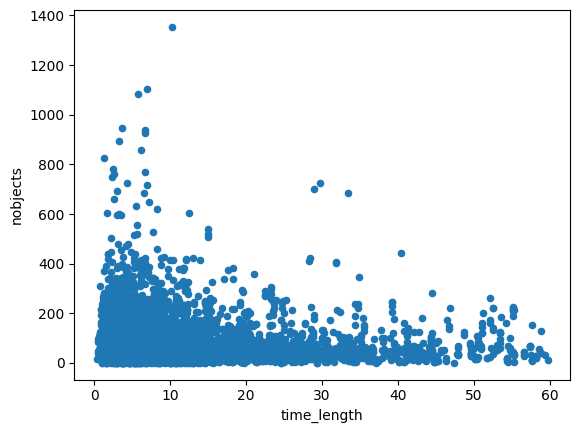

In [78]:
# зависимость длины плана от количества объектов в кадре
short_scenes.sample(10000).plot(kind='scatter', x='time_length', y='nobjects')

<Axes: xlabel='time_length', ylabel='brightness'>

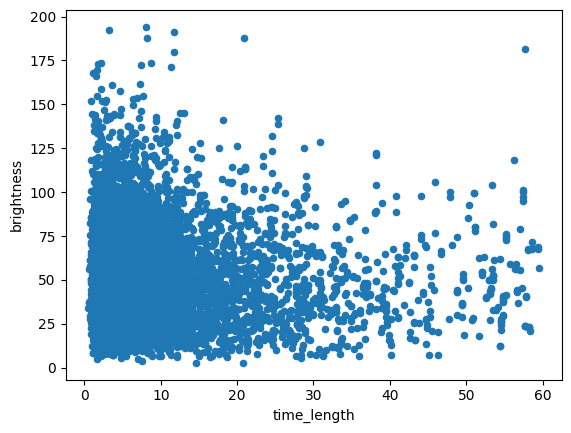

In [79]:
# зависимость длины плана от яркости кадра
short_scenes.sample(10000).plot(kind='scatter', x='time_length', y='brightness')

In [80]:
# летом фильмы покороче? возможно, это косвенное влияние жанра, а не любых летних фильмов
metadata_df.groupby('month')['mean_scene'].mean()

month
1    6.61
2    7.74
3    7.05
4    5.47
5    4.74
6    5.10
7    5.16
8    5.50
9    6.60
10   6.17
11   5.79
12   6.28
Name: mean_scene, dtype: float64

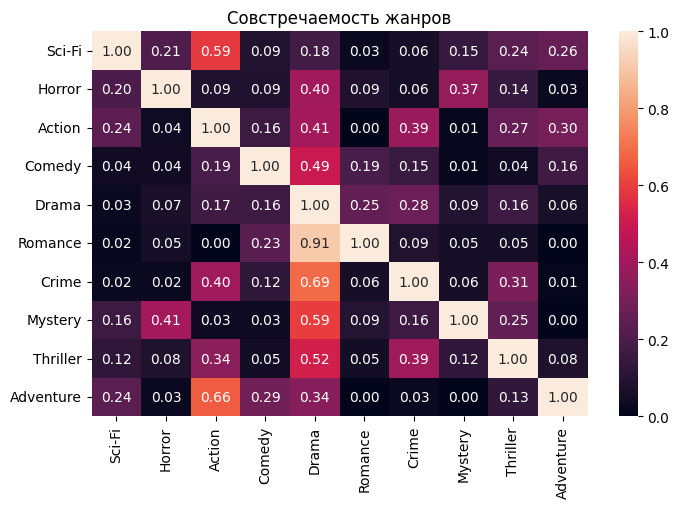

In [124]:
# построить тепловую карту совстречаемости жанров
for g in genres:
    metadata_df[g] = metadata_df['genres'].apply(lambda x: 1 if g in x else 0)

genre_matrix = metadata_df[genres].values

# Строим матрицу совстречаемости через матричное умножение
co_occurrence = np.dot(genre_matrix.T, genre_matrix)

# Преобразуем в DataFrame с названиями жанров
co_occurrence_df = pd.DataFrame(
    co_occurrence, 
    index=genres, 
    columns=genres
)


# Строим тепловую карту
df_norm = co_occurrence_df.div(co_occurrence_df.max(axis=1), axis=0)
from matplotlib.colors import LogNorm
plt.figure(figsize=(8, 5))
sns.heatmap(df_norm, annot=True, cmap='rocket', fmt='.2f', vmin=0, vmax=1)
plt.title('Совстречаемость жанров')
plt.show()

In [135]:
# среднее по жанрам и актам по различным параметрам
def genre_act_correlation(feature, extra_df=frames_df, num=3):

    agg_data = extra_df.groupby(['title', 'part'])[feature].mean().reset_index()
    
    # Создаем отдельные колонки для каждой части
    for part_num in range(1, num+1):
        part_data = agg_data[agg_data['part'] == part_num].set_index('title')[feature]
        metadata_df[f'part_{part_num}'] = metadata_df['title'].map(part_data)
    
    return metadata_df.groupby('genre')[['part_1', 'part_2', 'part_3']].mean()

In [138]:
genre_act_correlation('brightness').sort_values('part_1')

,part_1,part_2,part_3
genre,,,
crime,49.04,50.11,51.76
action,49.11,51.03,49.95
horror,50.41,45.55,40.04
sci-fi,52.40,53.88,50.00
thriller,52.46,47.95,50.50
drama,54.55,51.96,50.05
romance,55.58,52.50,53.16
history,56.80,59.98,55.16
war,57.87,59.28,60.69


In [141]:
genre_act_correlation('fsquare') #вау.

,part_1,part_2,part_3
genre,,,
action,0.02,0.02,0.02
comedy,0.02,0.02,0.02
crime,0.02,0.02,0.02
drama,0.02,0.02,0.02
history,0.02,0.02,0.02
horror,0.02,0.02,0.02
romance,0.02,0.02,0.02
sci-fi,0.02,0.02,0.02
thriller,0.02,0.02,0.02


In [143]:
genre_act_correlation('nobjects')

,part_1,part_2,part_3
genre,,,
action,129.87,122.73,119.63
comedy,191.01,189.67,186.26
crime,149.00,139.82,143.32
drama,168.33,152.64,145.08
history,171.65,171.96,155.22
horror,161.19,131.76,114.46
romance,163.28,165.21,155.13
sci-fi,148.31,145.76,137.02
thriller,155.38,133.02,144.08


In [144]:
genre_act_correlation('faces_bool')

,part_1,part_2,part_3
genre,,,
action,0.29,0.30,0.26
comedy,0.38,0.39,0.40
crime,0.33,0.34,0.32
drama,0.37,0.39,0.37
history,0.32,0.36,0.37
horror,0.34,0.34,0.29
romance,0.41,0.41,0.38
sci-fi,0.28,0.29,0.27
thriller,0.31,0.34,0.34


In [148]:
genre_act_correlation('time_length', extra_df=shot_df).sort_values('part_3')

,part_1,part_2,part_3
genre,,,
action,4.41,4.16,3.78
sci-fi,4.63,4.55,4.22
horror,6.22,5.90,5.24
war,5.84,5.52,5.47
history,5.83,5.94,6.26
crime,6.82,7.81,6.64
thriller,6.74,7.06,6.90
comedy,5.97,6.15,7.15
drama,6.87,7.46,7.22
